In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config Completer.use_jedi = False
import warnings
warnings.simplefilter(action='ignore')
from sklearn import preprocessing
sns.set(style="darkgrid", color_codes=True)

* loading the data...

In [2]:
df=pd.read_csv('../input/titanic/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


* just need to get rid of all the upper case latters for ease in the headers

In [3]:
df.drop(columns=['Ticket',],inplace=True)
df.columns=['passengerid','survived','pclass','name','sex','age','sibsp','parch','fare','cabin','embarked']

* Need to know howmany null values are there in each columns of the data, so that we can replace it by apropriate values 

* What i think is i'll just see the percent of null values in all of the column , if any of e'm has a very high percent of null values we'll drop and maybe explore a bit later! ,rest of e'm we'll fill with the mean value




passengerid     0.000000
survived        0.000000
pclass          0.000000
name            0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
cabin          77.104377
embarked        0.224467
dtype: float64


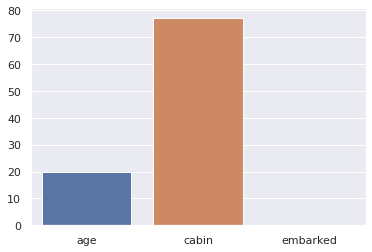

In [4]:
null=df.isnull().sum()# entire
percent=null/len(df)*100
print(percent)
percent=percent[percent>0]
sns.barplot(x=percent.index,y=percent)
plt.show()

In [5]:
print(df['embarked'].nunique())
print(df['embarked'].unique())


3
['S' 'C' 'Q' nan]


* All the string values to be changed to int if its that sort of a parameter
* Here embarked has 3 values we'll change it to 1,2,3 correspondingly
* Sex to 1 & 0, the same way
* The missing values in both categories can be changed to its avarage or what the most of the data tend towards

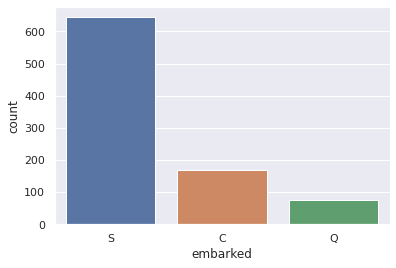

In [6]:
df['embarked-s']=np.zeros(len(df))
df['embarked-c']=np.zeros(len(df))
df['embarked-q']=np.zeros(len(df))
sns.countplot(df['embarked'])
plt.show()


* We can makes separate columns for different embarked values

In [7]:
# from the graph its fair assume the missing values to embarked=S
df['embarked'].fillna('S',inplace=True)
df.loc[df['embarked']=='S','embarked-s']=1
df.loc[df['embarked']=='C','embarked-c']=1
df.loc[df['embarked']=='Q','embarked-q']=1



* nan values of age replaced by the mean value

In [8]:
df.loc[df['sex']=='male','sex']=1
df.loc[df['sex']=='female','sex']=0
df['age'].fillna(df['age'].mean(),inplace=True)

In [9]:
df['cabin'].nunique()
# df['cabin'].unique()

147

In [10]:
df['owned_cabin']=df['cabin'].isnull().astype(int)
df['is_minor']=np.zeros(len(df))
df.loc[df['age']<18,'is_minor']=1

df['pclass_1']=np.zeros(len(df))
df['pclass_2']=np.zeros(len(df))
df['pclass_3']=np.zeros(len(df))
df.loc[df['pclass']==1,'pclass_1']=1
df.loc[df['pclass']==2,'pclass_2']=1
df.loc[df['pclass']==3,'pclass_3']=1


# df.drop('cabin',axis=1,inplace=True)
# df.drop('name',axis=1,inplace=True)

In [11]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.725028,0.188552,0.086420,0.771044,0.126824,0.242424,0.206510,0.551066
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.446751,0.391372,0.281141,0.420397,0.332962,0.428790,0.405028,0.497665
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# # EDA
Lets see what insights can we get from the graph ..


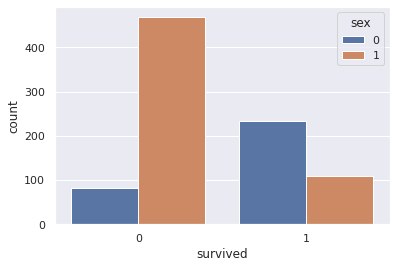

In [12]:
sns.countplot(data=df,x='survived',hue='sex')
plt.show()

#oh my god i did't know that

* most of the survivers were sex=0, also the death rate for sex=0 is very low compared to the other one


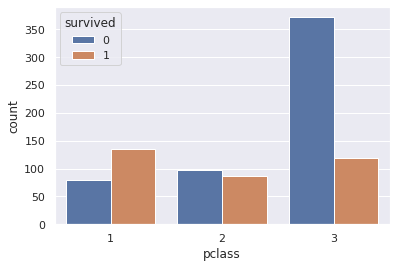

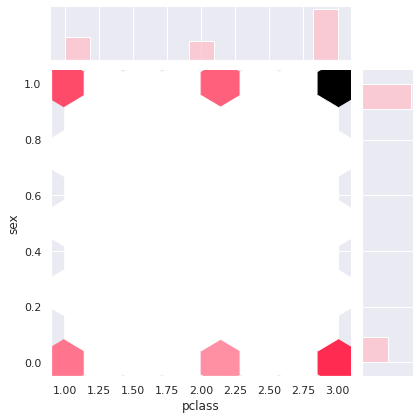

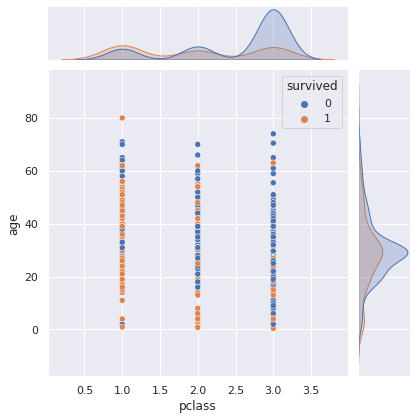

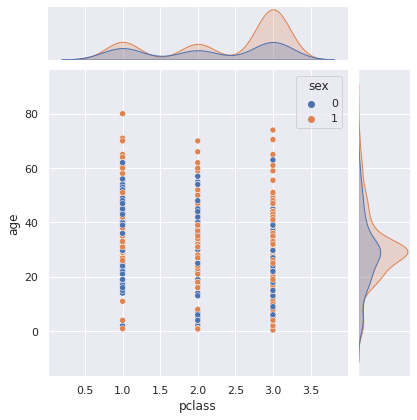

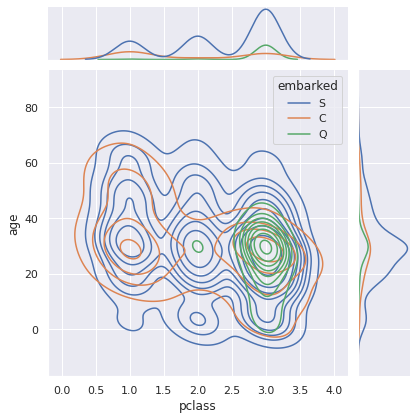

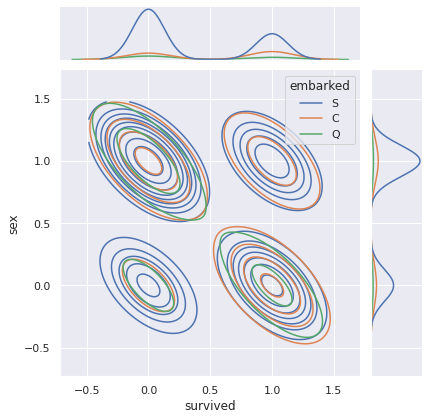

In [13]:
sns.set(style='darkgrid')
sns.countplot(df['pclass'],hue=df['survived'])
sns.jointplot(df['pclass'],df['sex'],kind='hex',color='pink')
sns.jointplot(df['pclass'],df['age'],hue=df['survived'])
sns.jointplot(df['pclass'],df['age'],hue=df['sex'])
sns.jointplot(df['pclass'],df['age'],hue=df['embarked'],kind='kde')
sns.jointplot(df['survived'],df['sex'],hue=df['embarked'],kind='kde')
plt.show()
# sns.distplot(df['age'],ax=ax[0][1],kde=True,)

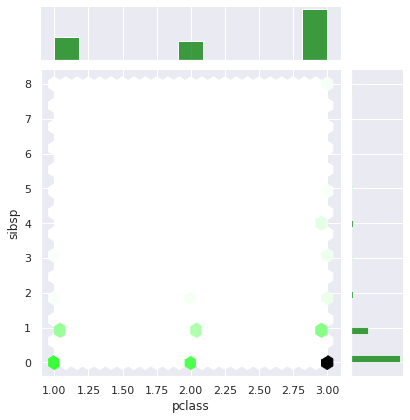

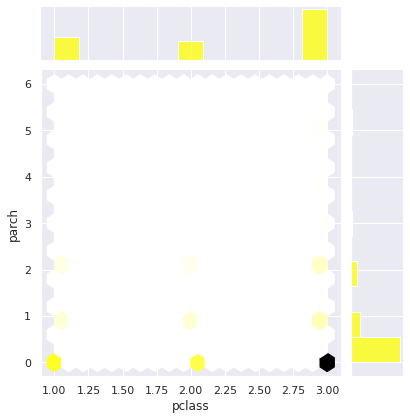

In [14]:
sns.jointplot(df['pclass'],df['sibsp'],kind='hex',color='green')
sns.jointplot(df['pclass'],df['parch'],kind='hex',color='yellow')
plt.show()

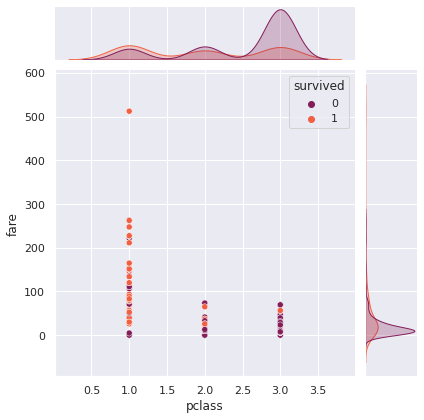

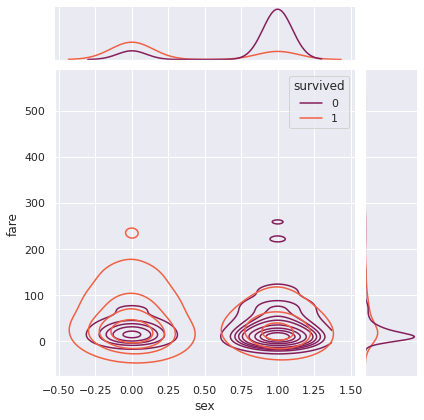

In [15]:
sns.jointplot(df['pclass'],df['fare'],hue=df['survived'],palette='rocket')
sns.jointplot(df['sex'],df['fare'],hue=df['survived'],kind='kde',palette ='rocket')

In [16]:
# sns.pairplot(df,hue='survived',palette='rocket',kind='kde')


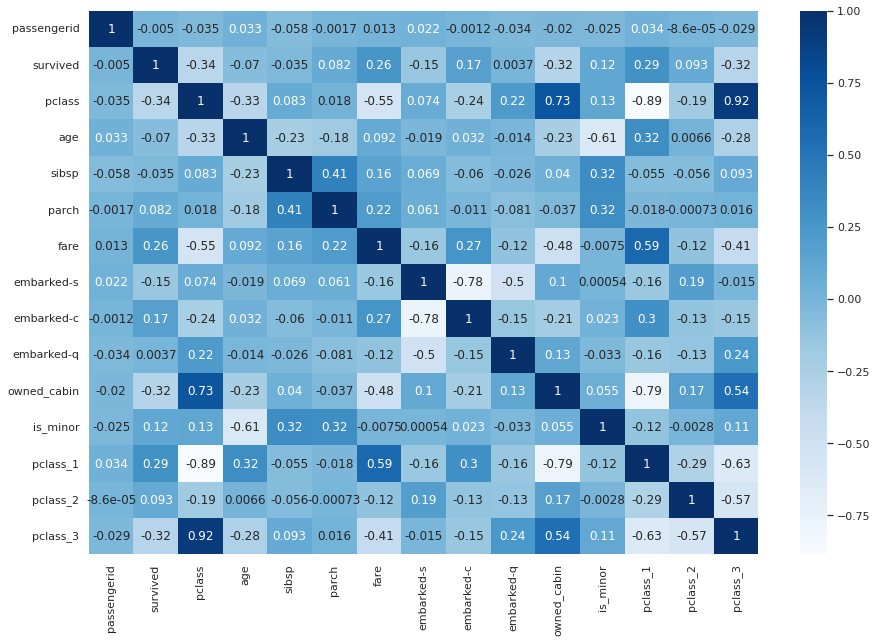

In [17]:
corr_matrix=df.corr()
figure=plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,cmap='Blues')
plt.show()

 # Model building and testing

importing bunch of things  for different algorithms

In [18]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import LinearSVC,SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

In [19]:
df.drop(columns={'pclass','name','cabin','embarked'},inplace=True)
df.head()

,passengerid,survived,sex,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
0,1,0,1,22.0,1,0,7.2500,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0
1,2,1,0,38.0,1,0,71.2833,0.0,1.0,0.0,0,0.0,1.0,0.0,0.0
2,3,1,0,26.0,0,0,7.9250,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0
3,4,1,0,35.0,1,0,53.1000,1.0,0.0,0.0,0,0.0,1.0,0.0,0.0
4,5,0,1,35.0,0,0,8.0500,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0


the data is already prepared, and we need separate sets of them for training and validation


In [20]:
X=df.drop(columns={'survived','is_minor'}, axis=1)
Y=df['survived']
train_x,validation_x,train_y,validation_y=train_test_split(X,Y.to_numpy(),test_size=0.2,random_state=10)
 

Lets try applying a Linear classifier

In [21]:
clf=LinearSVC(C=0.1,random_state=0)
clf.fit(train_x,train_y)
y_preds=clf.predict(validation_x)
accuracy=accuracy_score(validation_y,y_preds)
print(accuracy)

0.7541899441340782


The confusion matrix shows how have the model really made the predictions, where all the currect classification represented along the diagonal, and all the misclassified, and how they have been misclssified is given as the other elements of the matrix.(if a positive sample is classified -ve or all the other combinations of potential errors.)

In [22]:
confusion_matrix(validation_y,y_preds)


array([[112,   5],
       [ 39,  23]])

In [23]:
param_grid = {'C': 10. ** np.arange(-10, 4)}
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=6,)
grid_search.fit(train_x,train_y)


GridSearchCV(cv=6, estimator=LinearSVC(C=0.1, random_state=0),
             param_grid={'C': array([1.e-10, 1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03,
       1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])})

Here is  a parameter search with gridsearch, from sklearn.modelselection. As mensioned earlier the parameter c is really vital here since it controlls the distance from the descision to the margin boundary. What the grid search doea is, we can give it an array of different c values,the algorithm takes the values and cross valuidate through the entire data set and outputs the accuracies for each of the cross validated piece of data, then the avarage of the accuracies is taken as the representing accuracy for the perticular value of the parameter. 

In [24]:
print(grid_search.best_params_)
print(grid_search.best_score_)


{'C': 100.0}
0.7232706641978827


now using the best parameter from grid search to train the data and check on the validation set

In [25]:
res_data=pd.DataFrame(grid_search.cv_results_)
res_data

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003906,0.000164,0.001826,0.000053,0.0,{'C': 1e-10},0.605042,0.605042,0.605042,0.605042,0.610169,0.610169,0.606751,0.002417,13
1,0.003862,0.000014,0.001788,0.000019,0.0,{'C': 1e-09},0.605042,0.605042,0.605042,0.605042,0.610169,0.610169,0.606751,0.002417,13
2,0.003861,0.000037,0.001768,0.000029,0.0,{'C': 1e-08},0.605042,0.613445,0.613445,0.605042,0.610169,0.610169,0.609552,0.003458,11
3,0.003876,0.000036,0.001769,0.000026,0.0,{'C': 1e-07},0.579832,0.605042,0.605042,0.630252,0.644068,0.584746,0.608164,0.022904,12
4,0.004275,0.000026,0.001761,0.000017,0.000001,{'C': 1e-06},0.638655,0.647059,0.596639,0.647059,0.618644,0.601695,0.624958,0.020606,10
5,0.008081,0.000160,0.001958,0.000075,0.00001,{'C': 1e-05},0.672269,0.638655,0.588235,0.621849,0.635593,0.618644,0.629208,0.025261,9
6,0.029542,0.000236,0.002202,0.000021,0.0001,{'C': 0.0001},0.680672,0.689076,0.613445,0.630252,0.669492,0.644068,0.654501,0.027348,7
7,0.029541,0.000199,0.002194,0.000017,0.001,{'C': 0.001},0.655462,0.672269,0.663866,0.605042,0.694915,0.711864,0.667236,0.033668,5
8,0.029983,0.001181,0.002288,0.000207,0.01,{'C': 0.01},0.672269,0.680672,0.672269,0.689076,0.661017,0.703390,0.679782,0.013598,3
9,0.030146,0.000982,0.002264,0.000108,0.1,{'C': 0.1},0.739496,0.571429,0.722689,0.436975,0.703390,0.796610,0.661765,0.121354,6


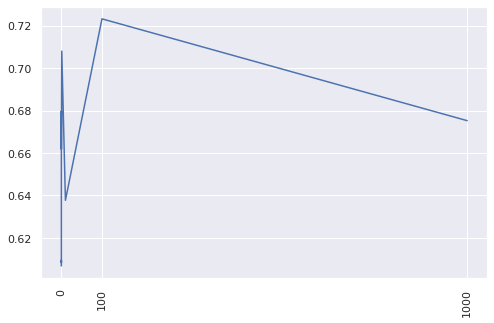

In [26]:
plt.figure(figsize=(8,5))
plt.plot(res_data['param_C'],res_data['mean_test_score'])
plt.xticks([0,100,1000],rotation=90)
plt.show()

In [27]:
y_preds = grid_search.predict(validation_x)
print('Accuracy: %.10f' % accuracy_score(validation_y, y_preds))

Accuracy: 0.7877094972


**Lets try applying logistic regression**

In [28]:
#zero mean and unit variance
sc=StandardScaler()
train_x=sc.fit_transform(train_x)
validation_x=sc.transform(validation_x)

In [29]:

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(train_x, train_y)
pred = lr_clf.predict(train_x)
clf_report = pd.DataFrame(classification_report(train_y, pred, output_dict=True))
print(clf_report)
print(accuracy_score(train_y, pred) )
    

                    0           1  accuracy   macro avg  weighted avg
precision    0.822894    0.795181  0.813202    0.809037      0.811996
recall       0.881944    0.707143  0.813202    0.794544      0.813202
f1-score     0.851397    0.748582  0.813202    0.799989      0.810964
support    432.000000  280.000000  0.813202  712.000000    712.000000
0.8132022471910112


In [30]:
pred = lr_clf.predict(validation_x)
clf_report = pd.DataFrame(classification_report(validation_y, pred, output_dict=True))
print(accuracy_score(validation_y, pred) )

0.8324022346368715


In [31]:
#preparing test_data 

test_data=pd.read_csv('../input/titanic/test.csv')

test_data['pclass_1']=np.zeros(len(test_data))
test_data['pclass_2']=np.zeros(len(test_data))
test_data['pclass_3']=np.zeros(len(test_data))
test_data.loc[test_data['Pclass']==1,'pclass_1']=1
test_data.loc[test_data['Pclass']==2,'pclass_2']=1
test_data.loc[test_data['Pclass']==3,'pclass_3']=1

test_data['embarked-s']=np.zeros(len(test_data))
test_data['embarked-c']=np.zeros(len(test_data))
test_data['embarked-q']=np.zeros(len(test_data))

test_data['Embarked'].fillna('S',inplace=True)
test_data.loc[test_data['Embarked']=='S','embarked-s']=1
test_data.loc[test_data['Embarked']=='C','embarked-c']=1
test_data.loc[test_data['Embarked']=='Q','embarked-q']=1

test_data['owned_cabin']=test_data['Cabin'].isnull().astype(int)
test_data['is_minor']=np.zeros(len(test_data))
test_data.loc[test_data['Age']<18,'is_minor']=1

test_data.loc[test_data['Sex']=='male','Sex']=1
test_data.loc[test_data['Sex']=='female','Sex']=0

test_data['Age'].fillna(test_data['Age'].mean(),inplace=True)
test_data['Fare'].fillna(test_data['Fare'].mean(),inplace=True)

test_data.drop(columns={'Name','Ticket','Cabin','Embarked','Pclass','is_minor'},inplace=True)



0.8324 seems the maximum accuracy logi regression can output given the feature representations

In [32]:
Survived=lr_clf.predict(test_data)
file=pd.DataFrame(test_data['PassengerId'])
file['Survived']=Survived

In [33]:
file.to_csv('submission.csv', header=True, index=False)